# HyperBench Tutorial 06: Framework Conversion

This notebook focuses on the framework conversion utilities built into HyperBench.

The notation used throughout the tutorial series is:

- ground-truth hyperspectral image (GT HSI / HR HSI): `(H, W, C)`
- low-resolution hyperspectral image (LR HSI): `(H/r, W/r, C)`
- high-resolution multispectral image (HR MSI): `(H, W, c)`
- spectral response function (SRF): `(c, C)`
- point spread function (PSF): `(k, k)`

This notebook covers:

- device detection for TensorFlow and PyTorch
- converting images from NumPy to TensorFlow and back
- converting images from NumPy to PyTorch and back
- converting matrices such as SRFs and PSFs
- the difference between image layout and matrix layout
- the role of the batch dimension
- round-trip consistency checks

## Related documentation

- `docs/adapters.md`
- `docs/model-integration.md`
- `docs/pipeline-interface.md`

## Imports

In [1]:
from pathlib import Path

import numpy as np

from hyperbench import (
    __version__,
    get_preferred_tensorflow_device,
    get_preferred_torch_device,
    get_tensorflow_device_info,
    get_torch_device_info,
    load_hsi,
    make_psf,
    normalize_image,
    numpy_hwc_to_tf_image,
    numpy_hwc_to_torch_image,
    numpy_to_tf_matrix,
    numpy_to_torch_matrix,
    print_data_stats,
    print_framework_device_summary,
    spectral_degradation,
    spatial_degradation,
    tf_image_to_numpy_hwc,
    tf_matrix_to_numpy,
    torch_image_to_numpy_hwc,
    torch_matrix_to_numpy,
    visualize_hsi,
)

print("HyperBench version:", __version__)

HyperBench version: 0.1.0


## Device summary

HyperBench exposes small helpers for checking framework availability and preferred devices.

In [2]:
print_framework_device_summary()

torch_info = get_torch_device_info()
tf_info = get_tensorflow_device_info()

print()
print("Preferred PyTorch device:", get_preferred_torch_device())
print("Preferred TensorFlow device:", get_preferred_tensorflow_device())

2026-03-30 07:05:35.177840: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-30 07:05:35.734668: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-30 07:05:35.913288: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-30 07:05:37.009949: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-30 07:05:43.795883: W tensorflow/compiler/tf2

Framework device summary
----------------------------------------
PyTorch:
  installed: True
  gpu_available: False
  gpu_count: 0
  preferred_device: cpu

TensorFlow:
  installed: True
  gpu_available: False
  gpu_count: 0
  preferred_device: /CPU:0

Preferred PyTorch device: cpu
Preferred TensorFlow device: /CPU:0


2026-03-30 07:05:51.612952: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:266] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## Load one scene and create one degradation case

The conversion examples below use one synthetic benchmark case so that the tensors represent realistic HyperBench inputs.

In [3]:
SCENE_PATH = Path("../data/DC_data.mat")
SCENE_KEY = "dc"

scene = load_hsi(SCENE_PATH, key=SCENE_KEY)
gt_hsi = normalize_image(scene)

psf = make_psf("gaussian", sigma=3.4, kernel_radius=7)

lr_hsi = spatial_degradation(
    image=gt_hsi,
    psf=psf,
    downsample_ratio=8,
    snr_db=30.0,
)

hr_msi, srf, band_specs, wavelengths = spectral_degradation(
    image=gt_hsi,
    snr_db=40.0,
    num_bands=4,
)

print_data_stats(gt_hsi, name="GT HSI")
print_data_stats(lr_hsi, name="LR HSI")
print_data_stats(hr_msi, name="HR MSI")

print("GT HSI shape (H, W, C):", gt_hsi.shape)
print("LR HSI shape (H/r, W/r, C):", lr_hsi.shape)
print("HR MSI shape (H, W, c):", hr_msi.shape)
print("SRF shape (c, C):", srf.shape)
print("PSF shape (k, k):", psf.shape)

GT HSI type: <class 'numpy.ndarray'>
GT HSI dtype: float32
GT HSI shape (H, W, B): (1280, 307, 191)
GT HSI min: 0.0
GT HSI max: 1.0
GT HSI mean: 0.2233569175004959
GT HSI std: 0.24737973511219025
LR HSI type: <class 'numpy.ndarray'>
LR HSI dtype: float32
LR HSI shape (H, W, B): (160, 38, 191)
LR HSI min: -0.026490479707717896
LR HSI max: 1.0593297481536865
LR HSI mean: 0.22119009494781494
LR HSI std: 0.22287006676197052
HR MSI type: <class 'numpy.ndarray'>
HR MSI dtype: float32
HR MSI shape (H, W, B): (1280, 307, 4)
HR MSI min: -0.000620176550000906
HR MSI max: 1.0153127908706665
HR MSI mean: 0.26445209980010986
HR MSI std: 0.2276136577129364
GT HSI shape (H, W, C): (1280, 307, 191)
LR HSI shape (H/r, W/r, C): (160, 38, 191)
HR MSI shape (H, W, c): (1280, 307, 4)
SRF shape (c, C): (4, 191)
PSF shape (k, k): (15, 15)


## HyperBench shape conventions

For the NumPy-facing API, HyperBench uses:

- images: `(H, W, C)` or `(H, W, c)`
- matrices: `(N, M)`

Framework-specific conversions preserve matrix layout, but image layout depends on the target backend.

In [4]:
print("GT HSI shape:", gt_hsi.shape)
print("LR HSI shape:", lr_hsi.shape)
print("HR MSI shape:", hr_msi.shape)
print("SRF shape:", srf.shape)
print("PSF shape:", psf.shape)

GT HSI shape: (1280, 307, 191)
LR HSI shape: (160, 38, 191)
HR MSI shape: (1280, 307, 4)
SRF shape: (4, 191)
PSF shape: (15, 15)


## NumPy to TensorFlow image conversion

TensorFlow image helpers preserve channel-last layout. If requested, a batch dimension is added in front.

In [5]:
tf_device = get_preferred_tensorflow_device()

try:
    import tensorflow as tf

    with tf.device(tf_device):
        lr_tf = numpy_hwc_to_tf_image(lr_hsi, add_batch_dim=True)
        hr_tf = numpy_hwc_to_tf_image(hr_msi, add_batch_dim=True)
        gt_tf = numpy_hwc_to_tf_image(gt_hsi, add_batch_dim=False)

    print("TensorFlow image tensor shapes:")
    print("  lr_tf:", tuple(lr_tf.shape))
    print("  hr_tf:", tuple(hr_tf.shape))
    print("  gt_tf:", tuple(gt_tf.shape))
except ImportError:
    print("TensorFlow is not installed in this environment.")

TensorFlow image tensor shapes:
  lr_tf: (1, 160, 38, 191)
  hr_tf: (1, 1280, 307, 4)
  gt_tf: (1280, 307, 191)


## TensorFlow back to NumPy

The inverse helpers remove the batch dimension when requested and return channel-last NumPy arrays again.

In [6]:
try:
    lr_tf_np = tf_image_to_numpy_hwc(lr_tf, remove_batch_dim=True)
    hr_tf_np = tf_image_to_numpy_hwc(hr_tf, remove_batch_dim=True)
    gt_tf_np = tf_image_to_numpy_hwc(gt_tf, remove_batch_dim=False)

    print("Back-converted TensorFlow image shapes:")
    print("  lr_tf_np:", lr_tf_np.shape)
    print("  hr_tf_np:", hr_tf_np.shape)
    print("  gt_tf_np:", gt_tf_np.shape)
except NameError:
    print("TensorFlow tensors are not available in this session.")

Back-converted TensorFlow image shapes:
  lr_tf_np: (160, 38, 191)
  hr_tf_np: (1280, 307, 4)
  gt_tf_np: (1280, 307, 191)


## TensorFlow round-trip differences

A correct conversion should preserve values up to floating-point precision.

In [7]:
try:
    print("TensorFlow round-trip max absolute differences:")
    print("  LR HSI:", float(np.max(np.abs(lr_hsi - lr_tf_np))))
    print("  HR MSI:", float(np.max(np.abs(hr_msi - hr_tf_np))))
    print("  GT HSI:", float(np.max(np.abs(gt_hsi - gt_tf_np))))
except NameError:
    print("TensorFlow tensors are not available in this session.")

TensorFlow round-trip max absolute differences:
  LR HSI: 0.0
  HR MSI: 0.0
  GT HSI: 0.0


## NumPy to TensorFlow matrix conversion

Matrices such as SRFs and PSFs are handled separately from images.

They remain two-dimensional.

In [8]:
try:
    srf_tf = numpy_to_tf_matrix(srf)
    psf_tf = numpy_to_tf_matrix(psf)

    print("TensorFlow matrix tensor shapes:")
    print("  srf_tf:", tuple(srf_tf.shape))
    print("  psf_tf:", tuple(psf_tf.shape))

    srf_tf_np = tf_matrix_to_numpy(srf_tf)
    psf_tf_np = tf_matrix_to_numpy(psf_tf)

    print("TensorFlow matrix round-trip max absolute differences:")
    print("  SRF:", float(np.max(np.abs(srf - srf_tf_np))))
    print("  PSF:", float(np.max(np.abs(psf - psf_tf_np))))
except NameError:
    print("TensorFlow tensors are not available in this session.")
except ImportError:
    print("TensorFlow is not installed in this environment.")

TensorFlow matrix tensor shapes:
  srf_tf: (4, 191)
  psf_tf: (15, 15)
TensorFlow matrix round-trip max absolute differences:
  SRF: 0.0
  PSF: 0.0


## NumPy to PyTorch image conversion

PyTorch image helpers convert channel-last NumPy arrays into channel-first tensors.

If `add_batch_dim=True`, the shape becomes `(1, C, H, W)` for hyperspectral data and `(1, c, H, W)` for multispectral data.

In [9]:
torch_device = get_preferred_torch_device()

try:
    import torch

    lr_torch = numpy_hwc_to_torch_image(lr_hsi, add_batch_dim=True, device=torch_device)
    hr_torch = numpy_hwc_to_torch_image(hr_msi, add_batch_dim=True, device=torch_device)
    gt_torch = numpy_hwc_to_torch_image(gt_hsi, add_batch_dim=False, device=torch_device)

    print("PyTorch image tensor shapes:")
    print("  lr_torch:", tuple(lr_torch.shape))
    print("  hr_torch:", tuple(hr_torch.shape))
    print("  gt_torch:", tuple(gt_torch.shape))
except ImportError:
    print("PyTorch is not installed in this environment.")

PyTorch image tensor shapes:
  lr_torch: (1, 191, 160, 38)
  hr_torch: (1, 4, 1280, 307)
  gt_torch: (191, 1280, 307)


## PyTorch back to NumPy

The inverse helpers convert channel-first tensors back into HyperBench's native channel-last layout.

In [10]:
try:
    lr_torch_np = torch_image_to_numpy_hwc(lr_torch, remove_batch_dim=True)
    hr_torch_np = torch_image_to_numpy_hwc(hr_torch, remove_batch_dim=True)
    gt_torch_np = torch_image_to_numpy_hwc(gt_torch, remove_batch_dim=False)

    print("Back-converted PyTorch image shapes:")
    print("  lr_torch_np:", lr_torch_np.shape)
    print("  hr_torch_np:", hr_torch_np.shape)
    print("  gt_torch_np:", gt_torch_np.shape)
except NameError:
    print("PyTorch tensors are not available in this session.")

Back-converted PyTorch image shapes:
  lr_torch_np: (160, 38, 191)
  hr_torch_np: (1280, 307, 4)
  gt_torch_np: (1280, 307, 191)


## PyTorch round-trip differences

In [11]:
try:
    print("PyTorch round-trip max absolute differences:")
    print("  LR HSI:", float(np.max(np.abs(lr_hsi - lr_torch_np))))
    print("  HR MSI:", float(np.max(np.abs(hr_msi - hr_torch_np))))
    print("  GT HSI:", float(np.max(np.abs(gt_hsi - gt_torch_np))))
except NameError:
    print("PyTorch tensors are not available in this session.")

PyTorch round-trip max absolute differences:
  LR HSI: 0.0
  HR MSI: 0.0
  GT HSI: 0.0


## NumPy to PyTorch matrix conversion

Matrices again stay two-dimensional.

In [12]:
try:
    srf_torch = numpy_to_torch_matrix(srf, device=torch_device)
    psf_torch = numpy_to_torch_matrix(psf, device=torch_device)

    print("PyTorch matrix tensor shapes:")
    print("  srf_torch:", tuple(srf_torch.shape))
    print("  psf_torch:", tuple(psf_torch.shape))

    srf_torch_np = torch_matrix_to_numpy(srf_torch)
    psf_torch_np = torch_matrix_to_numpy(psf_torch)

    print("PyTorch matrix round-trip max absolute differences:")
    print("  SRF:", float(np.max(np.abs(srf - srf_torch_np))))
    print("  PSF:", float(np.max(np.abs(psf - psf_torch_np))))
except NameError:
    print("PyTorch tensors are not available in this session.")
except ImportError:
    print("PyTorch is not installed in this environment.")

PyTorch matrix tensor shapes:
  srf_torch: (4, 191)
  psf_torch: (15, 15)
PyTorch matrix round-trip max absolute differences:
  SRF: 0.0
  PSF: 0.0


## Image tensors and matrix tensors play different roles

This distinction becomes important in real pipelines:

- images:
  - `LR_HSI` with shape `(H/r, W/r, C)`
  - `HR_MSI` with shape `(H, W, c)`
  - predicted `HR_HSI` with shape `(H, W, C)`

- matrices:
  - `srf` with shape `(c, C)`
  - `psf` with shape `(k, k)`

Images may require:
- channel reordering
- optional batch dimensions

Matrices typically do not.

## Visual check after round-trip conversion

To keep the framework conversion concrete, this section shows the recovered NumPy images after round-trip conversion.

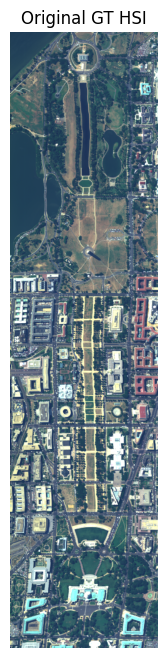

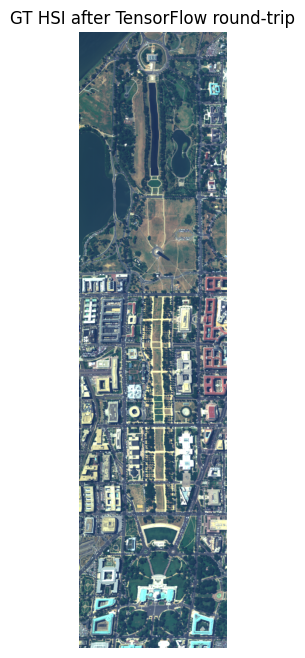

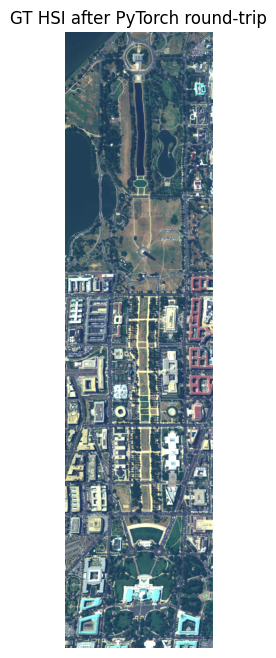

In [13]:
rgb_channels = (50, 35, 15)

visualize_hsi(gt_hsi, bands=rgb_channels, title="Original GT HSI")

try:
    visualize_hsi(gt_tf_np, bands=rgb_channels, title="GT HSI after TensorFlow round-trip")
except NameError:
    pass

try:
    visualize_hsi(gt_torch_np, bands=rgb_channels, title="GT HSI after PyTorch round-trip")
except NameError:
    pass

## Summary

This notebook covered the conversion utilities that make HyperBench framework-agnostic:

- device detection
- NumPy to TensorFlow image conversion
- NumPy to PyTorch image conversion
- matrix conversion for SRFs and PSFs
- channel-last vs channel-first image layouts
- optional batch dimensions
- round-trip consistency checks

These utilities are what allow HyperBench to present a clean Python-facing API while still supporting TensorFlow and PyTorch model pipelines.